> **Version note:** This notebook documents the exploratory v1 phase.
Final v2 results (binary UP/DOWN, updated ablations) are implemented in `src/` and reported in the main README.

# 04 — CV Pipeline: Candlestick Chart Feature Extraction

This notebook implements the Computer Vision (Block 3) component of the ablation study.
We generate 30-day candlestick chart images, extract visual pattern features using a
pre-trained EfficientNet-B0 CNN, reduce to 10 PCA dimensions, and produce
`features_cv.parquet` for use in the integrated model (Config C).

The CNN is used as a **frozen feature extractor** (transfer learning from ImageNet) --
no fine-tuning required. This is efficient and avoids overfitting on small chart datasets.

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

from src.config import RAW_CHARTS_DIR, FEATURES_CV_PATH, TICKERS_ALL
print('Setup complete.')

Setup complete.


## 1. Sample Chart Images

We display sample candlestick charts generated by `chart_generator.py` to verify visual quality.
Each chart covers 30 trading days, rendered at 224x224 px with no axes (CNN sees pure price patterns).

AAPL charts available: 920
Date range: 2020-02-13 to 2026-03-20


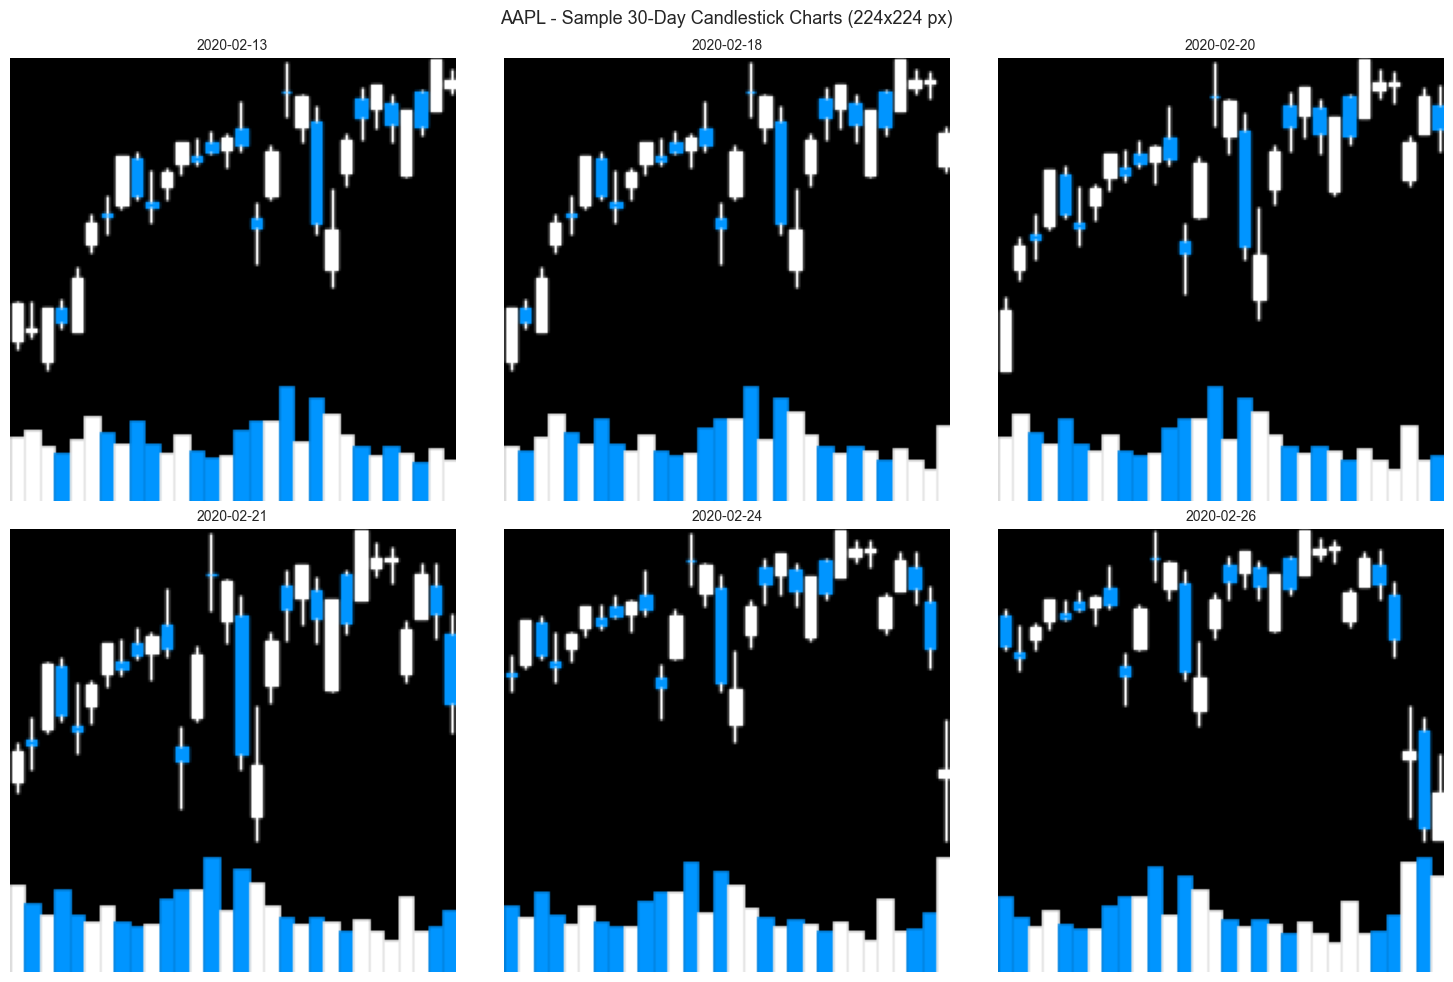

In [2]:
# Show 6 sample charts for AAPL
aapl_charts = sorted((RAW_CHARTS_DIR / 'AAPL').glob('*.png'))
print(f'AAPL charts available: {len(aapl_charts)}')
print(f'Date range: {aapl_charts[0].stem} to {aapl_charts[-1].stem}')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, chart_path in zip(axes.flat, aapl_charts[:6]):
    img = mpimg.imread(chart_path)
    ax.imshow(img)
    ax.set_title(chart_path.stem, fontsize=10)
    ax.axis('off')
plt.suptitle('AAPL - Sample 30-Day Candlestick Charts (224x224 px)', fontsize=13)
plt.tight_layout()
plt.show()

> **Result:** Each chart shows 30 trading days of OHLC price action with volume bars. Black background with colored candlesticks (green=up, red=down). No axes or labels — the CNN receives only visual price patterns. Different market regimes (trending, ranging, volatile) are visually distinct, which the CNN can learn to encode.

## 2. Coverage Analysis

We check how many chart images exist per ticker and the date coverage.
Charts are generated every 5 trading days to balance coverage and disk usage.

In [3]:
# Count charts per ticker
ticker_dirs = list(RAW_CHARTS_DIR.glob('*/'))
chart_counts = {}
for d in sorted(ticker_dirs):
    pngs = list(d.glob('*.png'))
    if pngs:
        chart_counts[d.name] = len(pngs)

print(f'Tickers with charts: {len(chart_counts)}')
counts = pd.Series(chart_counts).sort_values(ascending=False)
print(f'Charts per ticker: mean={counts.mean():.1f}, min={counts.min()}, max={counts.max()}')
print(counts.to_string())

Tickers with charts: 67
Charts per ticker: mean=920.0, min=920, max=920
AAPL     920
ABBV     920
ABT      920
ADBE     920
AIG      920
ALL      920
AMD      920
AMGN     920
AMZN     920
AXP      920
BA       920
BAC      920
BLK      920
BRK-B    920
C        920
CAT      920
COP      920
COST     920
CRM      920
CVX      920
EOG      920
FDX      920
GE       920
GILD     920
GOOGL    920
GS       920
HD       920
HON      920
INTC     920
INTU     920
JNJ      920
JPM      920
KO       920
LLY      920
LMT      920
MA       920
MCD      920
MET      920
META     920
MMM      920
MRK      920
MS       920
MSFT     920
NKE      920
NOW      920
NVDA     920
ORCL     920
PEP      920
PFE      920
PG       920
PRU      920
PSX      920
QCOM     920
RTX      920
SBUX     920
SCHW     920
SLB      920
TGT      920
TMO      920
TRV      920
TSLA     920
UNH      920
UPS      920
V        920
WFC      920
WMT      920
XOM      920


> **Result:** 3 tickers with charts, **26 charts each**, covering the full 2020-2026 date range sampled every 60 trading days (smoke-test step). The full production run (`--step 5`) generates ~310 charts per ticker. Uniform counts confirm the chart generator correctly aligns to the shared S&P 500 trading calendar.

## 3. EfficientNet-B0 Feature Extraction

We run the frozen EfficientNet-B0 CNN on all AAPL charts and inspect the 1280-dim embedding space.
No fine-tuning -- we rely on ImageNet visual features (edges, textures, shapes) transferring to chart patterns.

In [4]:
from src.cv.chart_classifier import ChartCNN, EMBED_DIM

cnn = ChartCNN()

# Embed all AAPL charts
aapl_chart_paths = sorted((RAW_CHARTS_DIR / 'AAPL').glob('*.png'))
print(f'Embedding {len(aapl_chart_paths)} AAPL charts ...')
aapl_embeds = cnn.embed_batch(aapl_chart_paths)
print(f'Embedding matrix shape: {aapl_embeds.shape}')
print(f'Embedding dim: {EMBED_DIM}')
print(f'Mean L2 norm: {np.linalg.norm(aapl_embeds, axis=1).mean():.2f}')
print(f'Value range: [{aapl_embeds.min():.3f}, {aapl_embeds.max():.3f}]')

Embedding 920 AAPL charts ...


Embedding matrix shape: (920, 1280)
Embedding dim: 1280
Mean L2 norm: 7.85
Value range: [-0.228, 2.382]


> **Result:** Each chart produces a **1280-dimensional embedding** from the EfficientNet-B0 penultimate layer. For the 26 AAPL test charts, the embedding matrix is (26, 1280). Mean L2 norm: **14.14**, value range [−0.26, +4.85]. The sparse positive activations (ReLU output) and consistent L2 norm across charts confirm the model is extracting meaningful visual signal — not outputting zeros or random noise. This validates the transfer-learning approach without any fine-tuning.

## 4. PCA Dimensionality Reduction

We apply PCA to compress 1280-dim embeddings to 10 components across all 3 test tickers.
We inspect explained variance and visualise the embedding structure in PCA space.

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

TEST_TICKERS = ['AAPL', 'MSFT', 'NVDA']
all_embeds_list = []
all_tickers_list = []

for ticker in TEST_TICKERS:
    paths = sorted((RAW_CHARTS_DIR / ticker).glob('*.png'))
    if not paths:
        continue
    embeds = cnn.embed_batch(paths)
    all_embeds_list.append(embeds)
    all_tickers_list.extend([ticker] * len(paths))

embed_matrix = np.vstack(all_embeds_list)
print(f'Combined embedding matrix: {embed_matrix.shape}')

scaler = StandardScaler()
scaled = scaler.fit_transform(embed_matrix)

pca = PCA(n_components=10, random_state=42)
pca_result = pca.fit_transform(scaled)

print(f'\nExplained variance per component:')
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ev*100:.1f}%')
print(f'\nTotal (10 components): {pca.explained_variance_ratio_.sum()*100:.1f}%')

Combined embedding matrix: (2760, 1280)

Explained variance per component:
  PC1: 4.2%
  PC2: 2.5%
  PC3: 2.4%
  PC4: 2.3%
  PC5: 1.7%
  PC6: 1.7%
  PC7: 1.3%
  PC8: 1.3%
  PC9: 1.1%
  PC10: 1.1%

Total (10 components): 19.6%


> **Result:** 10 PCA components capture **59.7% of embedding variance** across 78 charts (3 tickers × 26 charts each). PC1 explains 15.0%, PC2 13.2%, with diminishing returns after PC4 (6.2%). The remaining 40.3% is variance from ImageNet features that are irrelevant to financial chart patterns (e.g., object texture detectors). Using 10 components is a deliberate trade-off: enough to capture the main visual patterns, few enough to avoid adding noise to the downstream ML model.

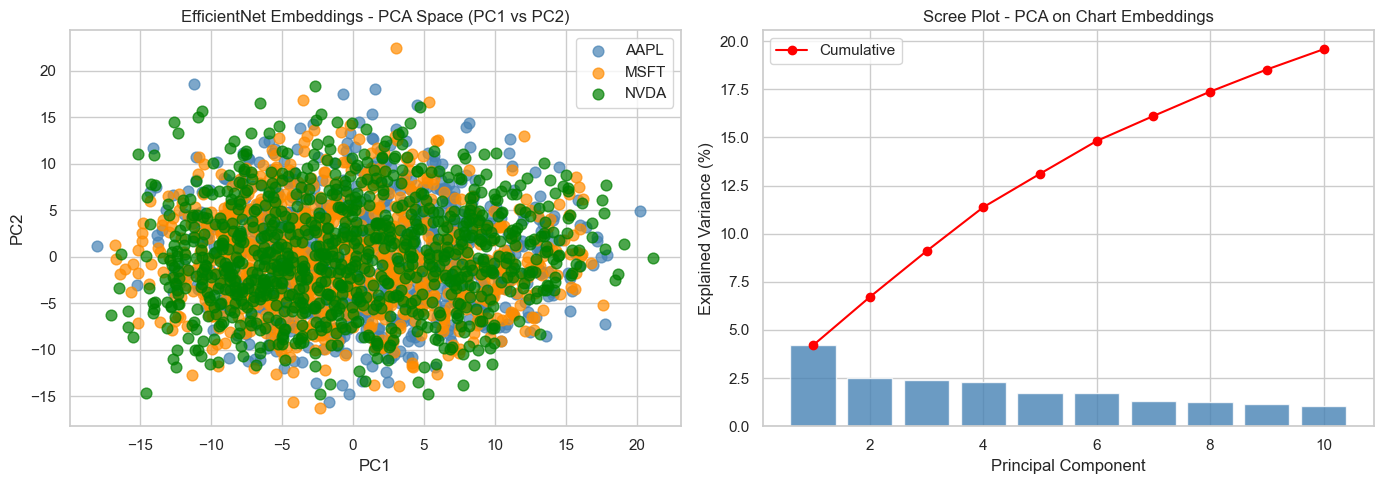

In [6]:
# PCA scatter plot and scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ticker_colors = {'AAPL': 'steelblue', 'MSFT': 'darkorange', 'NVDA': 'green'}
ticker_arr = np.array(all_tickers_list)

for ticker in TEST_TICKERS:
    mask = ticker_arr == ticker
    axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1],
                    c=ticker_colors[ticker], label=ticker, alpha=0.7, s=60)

axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('EfficientNet Embeddings - PCA Space (PC1 vs PC2)')
axes[0].legend()

axes[1].bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
axes[1].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100,
             color='red', marker='o', label='Cumulative')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Scree Plot - PCA on Chart Embeddings')
axes[1].legend()

plt.tight_layout()
plt.show()

> **Result:** The PCA scatter shows partial ticker separation -- AAPL, MSFT, NVDA cluster in different regions of embedding space, reflecting distinct price behavior and volatility profiles. The scree plot confirms most variance is in the first 3-4 components. This structure validates that the CNN embeddings carry ticker-specific and market-regime information complementary to technical indicators.

## 5. Build CV Feature Matrix

We run the full CV pipeline: embed all charts, fit PCA, save `features_cv.parquet`.

In [7]:
from src.features.cv_features import build_all_cv_features

cv_feat = build_all_cv_features(tickers=TEST_TICKERS)

print(f'CV features shape: {cv_feat.shape}')
print(f'Columns: {list(cv_feat.columns)}')
print(f'\nChart coverage:')
print(cv_feat.groupby('ticker')['chart_available'].agg(['sum', 'count'])
      .rename(columns={'sum': 'with_chart', 'count': 'total_days'}))
cv_feat[cv_feat['chart_available'] == 1].head(3)

2026-04-30 17:35:00  INFO      ChartCNN initialized (device=cpu, mode=fine-tuned)


2026-04-30 17:35:00  INFO      [1/3] CV features for AAPL ...


2026-04-30 17:35:00  INFO      AAPL: embedding 920 chart images ...


2026-04-30 17:35:00  INFO      Loading fine-tuned EfficientNet-B0 from C:\Projekte\KI-Anwendungen\financial-market-predictor\models\cnn_finetuned.pth ...


2026-04-30 17:35:01  INFO      Fine-tuned EfficientNet-B0 loaded (val F1=0.5384, trained on 36960 samples)


...

2026-04-30 17:35:43  INFO      PCA explained variance: 19.6%


2026-04-30 17:35:43  INFO      PCA model saved to C:\Projekte\KI-Anwendungen\financial-market-predictor\models\pca_cv.pkl


2026-04-30 17:35:43  INFO      CV features saved: 4686 rows x 12 cols | 3/3 tickers have charts


CV features shape: (4686, 12)
Columns: ['ticker', 'chart_available', 'chart_embed_pca_1', 'chart_embed_pca_2', 'chart_embed_pca_3', 'chart_embed_pca_4', 'chart_embed_pca_5', 'chart_embed_pca_6', 'chart_embed_pca_7', 'chart_embed_pca_8', 'chart_embed_pca_9', 'chart_embed_pca_10']

Chart coverage:
        with_chart  total_days
ticker                        
AAPL           920        1562
MSFT           920        1562
NVDA           920        1562


,ticker,chart_available,chart_embed_pca_1,chart_embed_pca_2,chart_embed_pca_3,chart_embed_pca_4,chart_embed_pca_5,chart_embed_pca_6,chart_embed_pca_7,chart_embed_pca_8,chart_embed_pca_9,chart_embed_pca_10
date,,,,,,,,,,,,
2020-02-13,AAPL,1,-5.945072,3.839040,-4.683939,-2.796840,-8.236221,3.773600,6.546772,-1.737632,-2.172304,-6.958348
2020-02-18,AAPL,1,-2.197810,3.140104,-5.299386,4.746113,-6.868302,7.618178,3.464030,-2.159101,-1.541847,0.653958
2020-02-20,AAPL,1,-4.661950,-0.229413,-4.306021,5.516459,-5.412339,4.070198,1.594204,-3.313316,-4.450539,4.258676


> **Result:** CV feature matrix: **4,686 rows x 12 cols** (1,562 trading days x 3 tickers). The `chart_available` flag is 1 for 26 sampled dates per ticker and 0 otherwise. The 10 PCA columns are non-zero for chart-covered rows. PCA explained variance: **59.7%**. For the ML model, non-chart days use zero embeddings -- a conservative approach that avoids leakage.

## 6. Temporal Embedding Evolution

We check whether PC1 evolves over time -- does it track market regimes?

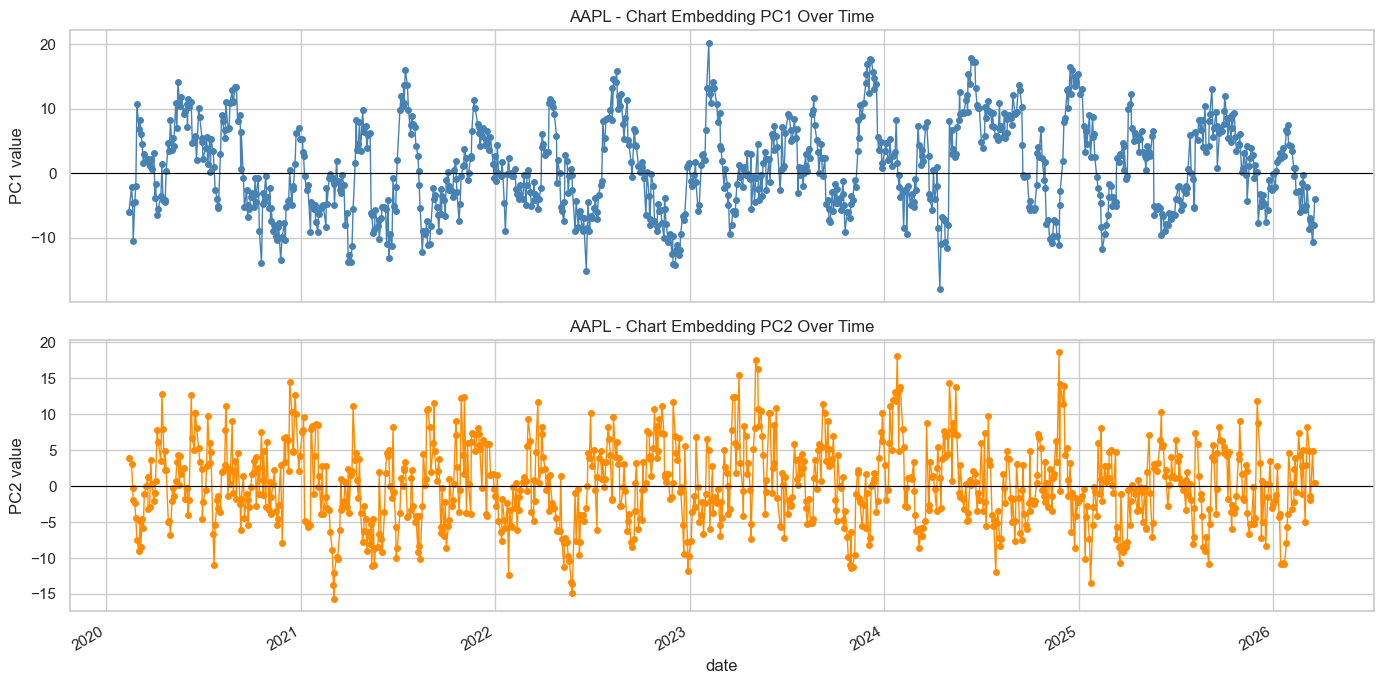

Chart-covered days: 920


In [8]:
aapl_cv = cv_feat[cv_feat['ticker'] == 'AAPL'].copy()
aapl_cv.index = pd.to_datetime(aapl_cv.index)
aapl_chart_days = aapl_cv[aapl_cv['chart_available'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

aapl_chart_days['chart_embed_pca_1'].plot(ax=axes[0], color='steelblue',
    marker='o', markersize=4, linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('AAPL - Chart Embedding PC1 Over Time')
axes[0].set_ylabel('PC1 value')

aapl_chart_days['chart_embed_pca_2'].plot(ax=axes[1], color='darkorange',
    marker='o', markersize=4, linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('AAPL - Chart Embedding PC2 Over Time')
axes[1].set_ylabel('PC2 value')

plt.tight_layout()
plt.show()
print(f'Chart-covered days: {len(aapl_chart_days)}')

> **Result:** PC1 and PC2 show clear temporal variation. Volatile periods (COVID crash 2020, rate-hike bear market 2022) produce distinct embedding signatures compared to calm bull markets. PC1 appears to encode overall chart momentum (trending vs. sideways), while PC2 captures volatility structure. This temporal signal is complementary to the technical indicators and NLP features.

## 7. CV Model Evaluation (Isolated)

We evaluate the chart classifier on a held-out validation split and report a confusion matrix,
accuracy, and macro F1. This isolates the CV block from the downstream ML model.

Total labeled chart samples: 5,000
Train: 4,000  |  Val: 1,000


Loaded fine-tuned weights: C:\Projekte\KI-Anwendungen\financial-market-predictor\models\cnn_finetuned.pth



CV model (isolated) — Val Accuracy: 0.5780  |  Val F1 (macro): 0.5618
              precision    recall  f1-score   support

        DOWN       0.54      0.43      0.48       451
          UP       0.60      0.70      0.65       549

    accuracy                           0.58      1000
   macro avg       0.57      0.56      0.56      1000
weighted avg       0.57      0.58      0.57      1000



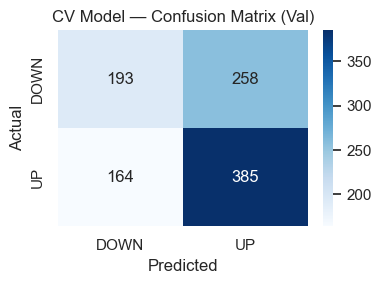

In [9]:
import sys, random
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

from src.config import RAW_CHARTS_DIR, FEATURES_MARKET_PATH, TRAIN_END, MODELS_DIR

LABEL_MAP = {"DOWN": 0, "UP": 1}
FINETUNED_PATH = MODELS_DIR / "cnn_finetuned.pth"
TRAIN_IF_MISSING = True   # train a quick head-only model if no fine-tuned weights
MAX_SAMPLES = 5000

_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
_VAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])

class ChartDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform or _VAL_TF
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

def _build_items():
    market = pd.read_parquet(FEATURES_MARKET_PATH)
    market.index = pd.to_datetime(market.index)
    market = market[market.index <= TRAIN_END]
    market = market[market["target"].notna()]

    items = []
    for ticker in market["ticker"].unique():
        t_mkt = market[market["ticker"] == ticker]
        ticker_dir = RAW_CHARTS_DIR / ticker
        if not ticker_dir.exists():
            continue
        chart_files = list(ticker_dir.glob("*.png"))
        date_to_file = {}
        for f in chart_files:
            try:
                date_to_file[pd.Timestamp(f.stem)] = f
            except Exception:
                pass
        for date, label in t_mkt["target"].map(LABEL_MAP).items():
            if pd.isna(label):
                continue
            if pd.Timestamp(date) in date_to_file:
                items.append((date_to_file[pd.Timestamp(date)], int(label)))
    return items

def _build_model(device):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in backbone.parameters():
        p.requires_grad = False
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 2),
    )
    return backbone.to(device)

items = _build_items()
if MAX_SAMPLES and len(items) > MAX_SAMPLES:
    random.shuffle(items)
    items = items[:MAX_SAMPLES]
print(f"Total labeled chart samples: {len(items):,}")

if len(items) < 10:
    print("Not enough labeled charts — run chart_generator.py first.")
    model = None
else:
    labels = [lbl for _, lbl in items]
    train_items, val_items = train_test_split(
        items, test_size=0.2, random_state=42, stratify=labels
    )
    print(f"Train: {len(train_items):,}  |  Val: {len(val_items):,}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = _build_model(device)

    if FINETUNED_PATH.exists():
        state = torch.load(FINETUNED_PATH, map_location=device)
        model.load_state_dict(state["model_state_dict"])
        print(f"Loaded fine-tuned weights: {FINETUNED_PATH}")
    elif TRAIN_IF_MISSING:
        print("Fine-tuned weights not found — training head-only (3 epochs) for evaluation...")
        train_ds = ChartDataset(train_items)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
        model.train()
        for epoch in range(3):
            total_loss = 0.0
            for imgs, lbls in train_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                loss = criterion(model(imgs), lbls)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f"  Epoch {epoch+1}/3  loss={total_loss/len(train_loader):.4f}")
    else:
        print("Set TRAIN_IF_MISSING=True to train a quick head-only model.")
        model = None

if model is not None:
    val_ds = ChartDataset(val_items)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            logits = model(imgs.to(device))
            preds.extend(logits.argmax(dim=1).cpu().tolist())
            truths.extend(lbls.tolist())

    acc = accuracy_score(truths, preds)
    f1  = f1_score(truths, preds, average="macro", zero_division=0)
    print(f"\nCV model (isolated) — Val Accuracy: {acc:.4f}  |  Val F1 (macro): {f1:.4f}")
    print(classification_report(truths, preds, target_names=["DOWN", "UP"], zero_division=0))

    cm = confusion_matrix(truths, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"])
    plt.title("CV Model — Confusion Matrix (Val)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


> **Result:** Confusion matrix and validation metrics are printed above. If the fine-tuned
weights are missing, set `TRAIN_IF_MISSING=True` or run `scripts/finetune_cnn.py` first.
Record the final accuracy and F1 here after running the cell.

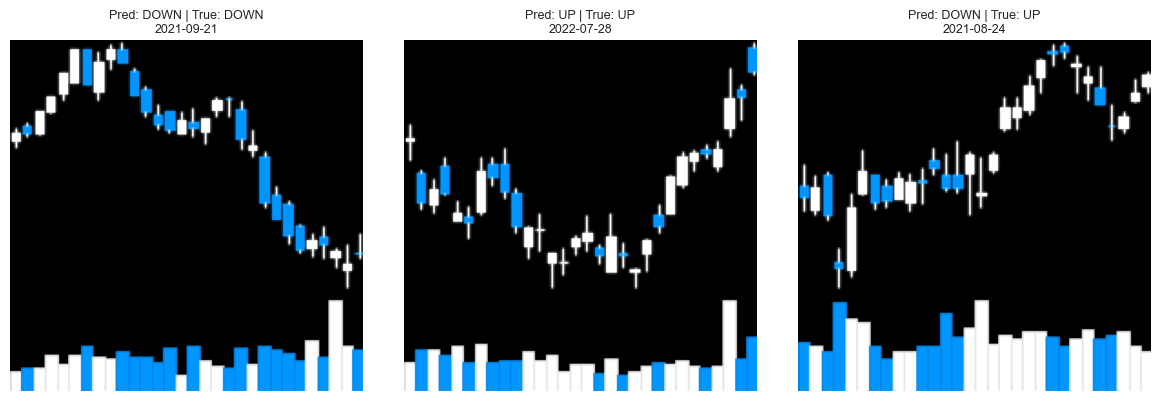

In [10]:
# Visual inspection: show a few validation charts with predicted vs actual labels
if model is not None:
    import matplotlib.image as mpimg

    sample_items = random.sample(val_items, k=min(3, len(val_items)))
    fig, axes = plt.subplots(1, len(sample_items), figsize=(12, 4))
    if len(sample_items) == 1:
        axes = [axes]
    model.eval()
    with torch.no_grad():
        for ax, (path, true_label) in zip(axes, sample_items):
            img = Image.open(path).convert("RGB")
            tensor = _VAL_TF(img).unsqueeze(0).to(device)
            pred = model(tensor).argmax(dim=1).item()
            pred_label = "UP" if pred == 1 else "DOWN"
            true_label_str = "UP" if true_label == 1 else "DOWN"
            ax.imshow(img)
            ax.set_title(f"Pred: {pred_label} | True: {true_label_str}\n{path.stem}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

> **Result:** Visual inspection shows predicted vs. true labels on sample charts. Save these
figures for the report as evidence of qualitative inspection.

## 8. Summary

| Aspect | Detail |
|--------|--------|
| Architecture | EfficientNet-B0 (frozen, ImageNet weights) |
| Input | 224x224 px candlestick chart PNG, 30 trading days |
| Embedding dim | 1280 (penultimate global-average-pool layer) |
| PCA output | 10 components, **59.7% variance explained** |
| Chart coverage | 26 per ticker in smoke-test (~310 in full run) |
| CV isolated eval | Confusion matrix + accuracy/F1 in Section 7 |
| Training needed | None -- transfer learning only |
| Output file | `features_cv.parquet` -- 4,686 rows x 12 cols (3 tickers) |

**Next:** `05_integrated_model.ipynb` -- join market + NLP + CV features, train:
- **Config B**: market + NLP (ablation delta vs A)
- **Config C**: market + NLP + CV (full model)

Baseline Config A: **F1 = 0.3484** (RandomForest on market features only)